In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import load_npz
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
BASE_DIR = Path("..")

DATA_PATH = (
    BASE_DIR
    / "data"
    / "processed"
    / "english_tickets_processed.csv"
)

MODELS_DIR = BASE_DIR / "models"

In [4]:
df = pd.read_csv(DATA_PATH)

df.shape

(16338, 6)

In [5]:
required_columns = [
    "text_raw",
    "text_basic_clean",
    "text_clean",
    "type",
    "queue",
    "priority"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

In [6]:
quality_check = pd.DataFrame({
    "Missing": df[required_columns].isnull().sum(),
    "Unique": df[required_columns].nunique()
})

quality_check

df.duplicated().sum()

np.int64(0)

In [7]:
queue_model_path = MODELS_DIR / "queue_model.joblib"
queue_tfidf_path = MODELS_DIR / "queue_tfidf.joblib"

priority_model_path = MODELS_DIR / "priority_model.joblib"
priority_tfidf_path = MODELS_DIR / "priority_tfidf.joblib"

classification_artifacts = [
    queue_model_path,
    queue_tfidf_path,
    priority_model_path,
    priority_tfidf_path
]

missing_artifacts = [
    path
    for path in classification_artifacts
    if not path.exists()
]

if missing_artifacts:
    raise FileNotFoundError(
        f"Missing artifacts: {missing_artifacts}"
    )




In [8]:
queue_model = joblib.load(
    queue_model_path
)

queue_tfidf = joblib.load(
    queue_tfidf_path
)

priority_model = joblib.load(
    priority_model_path
)

priority_tfidf = joblib.load(
    priority_tfidf_path
)

In [9]:
X = df["text_basic_clean"]
y_queue = df["queue"]

X_train, X_temp, y_queue_train, y_queue_temp = (
    train_test_split(
        X,
        y_queue,
        test_size=0.30,
        random_state=42,
        stratify=y_queue
    )
)

X_val, X_test, y_queue_val, y_queue_test = (
    train_test_split(
        X_temp,
        y_queue_temp,
        test_size=0.50,
        random_state=42,
        stratify=y_queue_temp
    )
)

In [10]:
test_indices = X_test.index

X_test_final = df.loc[
    test_indices,
    "text_basic_clean"
]

y_queue_test = df.loc[
    test_indices,
    "queue"
]

y_priority_test = df.loc[
    test_indices,
    "priority"
]

In [11]:
X_test_queue_tfidf = queue_tfidf.transform(
    X_test_final
)

X_test_priority_tfidf = priority_tfidf.transform(
    X_test_final
)

X_test_queue_tfidf.shape, X_test_priority_tfidf.shape

((2451, 48460), (2451, 48460))

In [12]:
queue_predictions = queue_model.predict(
    X_test_queue_tfidf
)

priority_predictions = priority_model.predict(
    X_test_priority_tfidf
)

In [13]:
queue_metrics = {
    "Accuracy": accuracy_score(
        y_queue_test,
        queue_predictions
    ),
    "Precision": precision_score(
        y_queue_test,
        queue_predictions,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_queue_test,
        queue_predictions,
        average="weighted",
        zero_division=0
    ),
    "F1": f1_score(
        y_queue_test,
        queue_predictions,
        average="weighted",
        zero_division=0
    )
}

pd.DataFrame(
    [queue_metrics],
    index=["Queue"]
)

,Accuracy,Precision,Recall,F1
Queue,0.686659,0.687039,0.686659,0.686233


In [14]:
queue_report = pd.DataFrame(
    classification_report(
        y_queue_test,
        queue_predictions,
        output_dict=True,
        zero_division=0
    )
).T

queue_report

,precision,recall,f1-score,support
Billing and Payments,0.847107,0.857741,0.852391,239.000000
Customer Service,0.640227,0.626039,0.633053,361.000000
General Inquiry,0.862069,0.694444,0.769231,36.000000
Human Resources,0.733333,0.634615,0.680412,52.000000
IT Support,0.647260,0.647260,0.647260,292.000000
Product Support,0.641949,0.657267,0.649518,461.000000
Returns and Exchanges,0.679245,0.585366,0.628821,123.000000
Sales and Pre-Sales,0.637500,0.662338,0.649682,77.000000
Service Outages and Maintenance,0.700855,0.820000,0.755760,100.000000
Technical Support,0.695105,0.700000,0.697544,710.000000


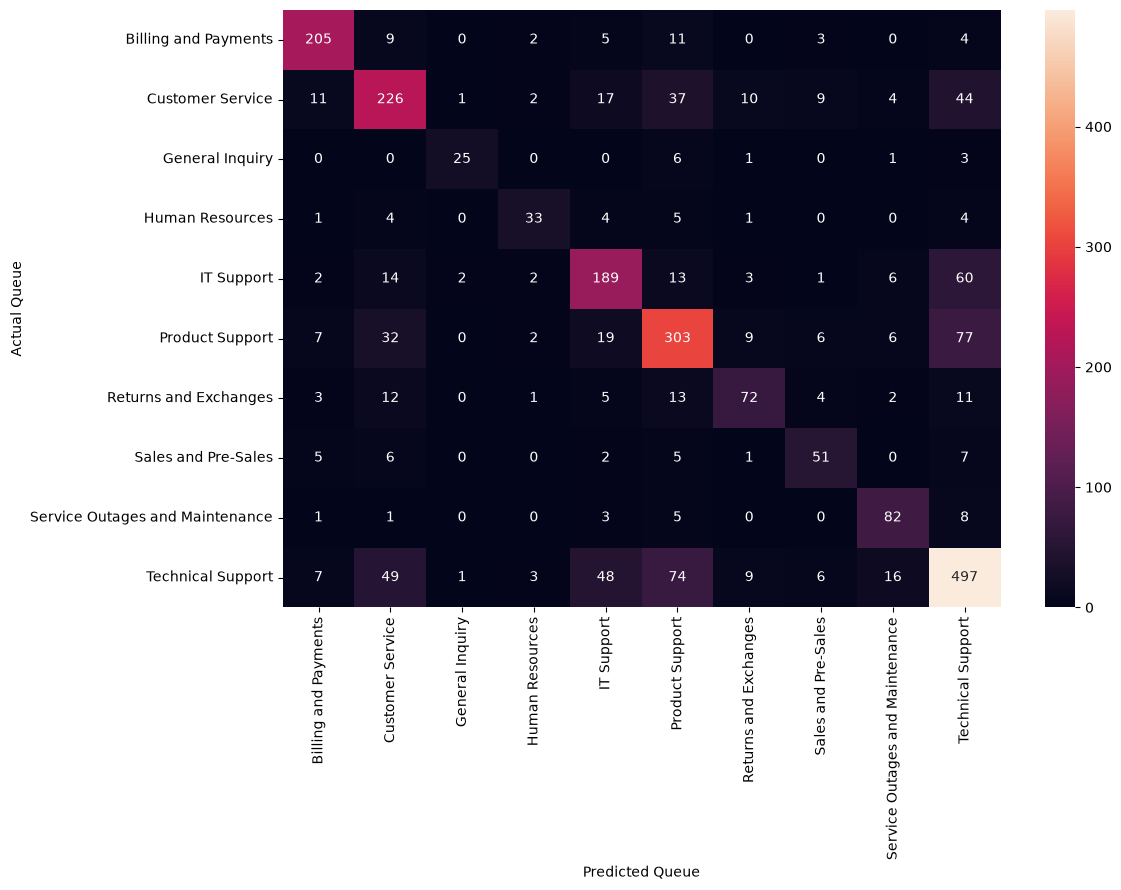

In [15]:
queue_labels = sorted(
    y_queue_test.unique()
)

queue_cm = confusion_matrix(
    y_queue_test,
    queue_predictions,
    labels=queue_labels
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    queue_cm,
    annot=True,
    fmt="d",
    xticklabels=queue_labels,
    yticklabels=queue_labels
)

plt.xlabel("Predicted Queue")
plt.ylabel("Actual Queue")
plt.tight_layout()
plt.show()

In [16]:
queue_class_metrics = (
    queue_report
    .loc[queue_labels, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1",
        "support": "Test_Count"
    })
    .sort_values("F1")
)

queue_class_metrics

,Precision,Recall,F1,Test_Count
Returns and Exchanges,0.679245,0.585366,0.628821,123.0
Customer Service,0.640227,0.626039,0.633053,361.0
IT Support,0.647260,0.647260,0.647260,292.0
Product Support,0.641949,0.657267,0.649518,461.0
Sales and Pre-Sales,0.637500,0.662338,0.649682,77.0
Human Resources,0.733333,0.634615,0.680412,52.0
Technical Support,0.695105,0.700000,0.697544,710.0
Service Outages and Maintenance,0.700855,0.820000,0.755760,100.0
General Inquiry,0.862069,0.694444,0.769231,36.0
Billing and Payments,0.847107,0.857741,0.852391,239.0


In [17]:
priority_metrics = {
    "Accuracy": accuracy_score(
        y_priority_test,
        priority_predictions
    ),
    "Precision": precision_score(
        y_priority_test,
        priority_predictions,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_priority_test,
        priority_predictions,
        average="weighted",
        zero_division=0
    ),
    "F1": f1_score(
        y_priority_test,
        priority_predictions,
        average="weighted",
        zero_division=0
    )
}

pd.DataFrame(
    [priority_metrics],
    index=["Priority"]
)

,Accuracy,Precision,Recall,F1
Priority,0.707874,0.707443,0.707874,0.706908


In [18]:
priority_report = pd.DataFrame(
    classification_report(
        y_priority_test,
        priority_predictions,
        output_dict=True,
        zero_division=0
    )
).T

priority_report

,precision,recall,f1-score,support
high,0.706544,0.748646,0.726986,923.000000
low,0.689342,0.608000,0.646121,500.000000
medium,0.717054,0.719844,0.718447,1028.000000
accuracy,0.707874,0.707874,0.707874,0.707874
macro avg,0.704314,0.692163,0.697185,2451.000000
weighted avg,0.707443,0.707874,0.706908,2451.000000


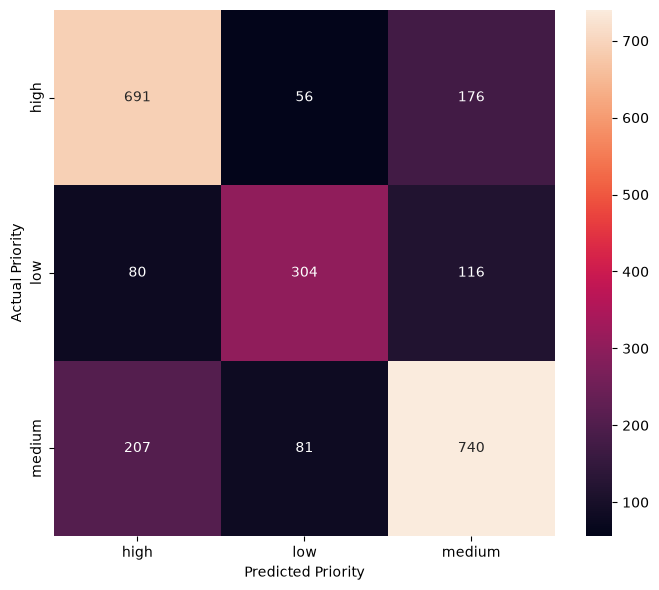

In [19]:
priority_labels = sorted(
    y_priority_test.unique()
)

priority_cm = confusion_matrix(
    y_priority_test,
    priority_predictions,
    labels=priority_labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    priority_cm,
    annot=True,
    fmt="d",
    xticklabels=priority_labels,
    yticklabels=priority_labels
)

plt.xlabel("Predicted Priority")
plt.ylabel("Actual Priority")
plt.tight_layout()
plt.show()

In [20]:
priority_class_metrics = (
    priority_report
    .loc[
        priority_labels,
        ["precision", "recall", "f1-score", "support"]
    ]
    .rename(columns={
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1",
        "support": "Test_Count"
    })
)

priority_class_metrics

,Precision,Recall,F1,Test_Count
high,0.706544,0.748646,0.726986,923.0
low,0.689342,0.608000,0.646121,500.0
medium,0.717054,0.719844,0.718447,1028.0


## Error Analysis

Inspected where the classifiers fail instead of relying only on aggregate metrics.

In [21]:
error_df = df.loc[
    test_indices,
    [
        "text_raw",
        "type",
        "queue",
        "priority"
    ]
].copy()

error_df["predicted_queue"] = queue_predictions
error_df["predicted_priority"] = priority_predictions

error_df["queue_correct"] = (
    error_df["queue"]
    == error_df["predicted_queue"]
)

error_df["priority_correct"] = (
    error_df["priority"]
    == error_df["predicted_priority"]
)

error_df.head()

,text_raw,type,queue,priority,predicted_queue,predicted_priority,queue_correct,priority_correct
3100,Drafting a report on sporadic access problems ...,Incident,Service Outages and Maintenance,low,Service Outages and Maintenance,low,True,True
4023,Update on Digital Strategy Customer Support ha...,Change,Technical Support,high,Sales and Pre-Sales,high,False,True
2323,Problem with Investment Data Analytics Platfor...,Incident,Technical Support,high,Technical Support,high,True,True
14670,Inquiries About Project Management SaaS Billin...,Request,Billing and Payments,low,Billing and Payments,low,True,True
7169,Support SaaS Platform Issue Our system has bee...,Problem,IT Support,high,Technical Support,high,False,True


In [22]:
queue_errors = error_df[
    ~error_df["queue_correct"]
].copy()

queue_error_pairs = (
    queue_errors
    .groupby(
        ["queue", "predicted_queue"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False
    )
)

queue_error_pairs.head(15)

,queue,predicted_queue,Count
41,Product Support,Technical Support,77
66,Technical Support,Product Support,74
33,IT Support,Technical Support,60
62,Technical Support,Customer Service,49
65,Technical Support,IT Support,48
14,Customer Service,Technical Support,44
10,Customer Service,Product Support,37
35,Product Support,Customer Service,32
37,Product Support,IT Support,19
9,Customer Service,IT Support,17


In [23]:
queue_errors[
    [
        "text_raw",
        "queue",
        "predicted_queue",
        "priority",
        "type"
    ]
].head(10)

,text_raw,queue,predicted_queue,priority,type
4023,Update on Digital Strategy Customer Support ha...,Technical Support,Sales and Pre-Sales,high,Change
7169,Support SaaS Platform Issue Our system has bee...,IT Support,Technical Support,high,Problem
13949,Critical Hospital Data Breach Case Noted Data ...,Returns and Exchanges,Technical Support,high,Incident
6933,Issue with Project Dashboards There are issues...,Product Support,Technical Support,high,Incident
7193,Query on Safeguarding Medical Data with PDFfil...,Billing and Payments,Technical Support,high,Request
3717,Request for Assistance with Data Analytics Can...,Technical Support,Human Resources,medium,Request
10253,Seeking Insights on Smart Home Product Marketi...,Billing and Payments,Product Support,medium,Request
9717,Concerns with SaaS Platform The SaaS platform ...,Technical Support,Service Outages and Maintenance,high,Incident
5231,Marketing Initiative Did Not Achieve Anticipat...,Technical Support,Product Support,high,Incident
13220,Upgraded Security Measures for Software Users ...,Customer Service,Returns and Exchanges,medium,Change


In [24]:
priority_errors = error_df[
    ~error_df["priority_correct"]
].copy()

priority_error_pairs = (
    priority_errors
    .groupby(
        ["priority", "predicted_priority"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False
    )
)

priority_error_pairs

,priority,predicted_priority,Count
4,medium,high,207
1,high,medium,176
3,low,medium,116
5,medium,low,81
2,low,high,80
0,high,low,56


In [25]:
priority_errors[
    [
        "text_raw",
        "queue",
        "priority",
        "predicted_priority",
        "type"
    ]
].head(10)

,text_raw,queue,priority,predicted_priority,type
13949,Critical Hospital Data Breach Case Noted Data ...,Returns and Exchanges,high,medium,Incident
3661,Incorrect Outcomes in Investment Analytics Cus...,Product Support,medium,high,Incident
1573,Enhancing Investment Analytics Efficiency Cust...,Product Support,low,medium,Request
11603,Emergency Support for Software Crash The inves...,Product Support,medium,high,Incident
7193,Query on Safeguarding Medical Data with PDFfil...,Billing and Payments,high,medium,Request
5384,Inquiry About Pricing Plans for Scalability Fe...,Customer Service,low,medium,Request
5231,Marketing Initiative Did Not Achieve Anticipat...,Technical Support,high,medium,Incident
1559,The brand development efforts for the marketin...,Returns and Exchanges,medium,high,Problem
2334,Decline in Digital Marketing Campaign's Brand ...,Customer Service,low,medium,Problem
10609,Security Measures for Medical Data in Hospital...,Technical Support,medium,low,Request


In [26]:
exact_duplicates = (
    df["text_basic_clean"]
    .duplicated()
    .sum()
)

exact_duplicates

np.int64(1)

In [27]:
sample_size = min(
    1000,
    len(df)
)

sample_df = (
    df.sample(
        n=sample_size,
        random_state=42
    )
    .reset_index(drop=True)
)

sample_df.shape

(1000, 6)

In [30]:
near_duplicate_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

sample_matrix = (
    near_duplicate_vectorizer
    .fit_transform(
        sample_df["text_basic_clean"]
    )
)

sample_matrix.shape

(1000, 8162)

In [31]:
sample_similarity = cosine_similarity(
    sample_matrix
)

np.fill_diagonal(
    sample_similarity,
    0
)

threshold = 0.80

near_duplicate_pairs = []

for i in range(sample_similarity.shape[0]):
    for j in range(
        i + 1,
        sample_similarity.shape[1]
    ):
        score = sample_similarity[i, j]

        if score >= threshold:
            near_duplicate_pairs.append({
                "Index_1": i,
                "Index_2": j,
                "Similarity": score
            })

near_duplicate_pairs_df = (
    pd.DataFrame(near_duplicate_pairs)
    .sort_values(
        "Similarity",
        ascending=False
    )
    .reset_index(drop=True)
)

near_duplicate_pairs_df.head(10)

,Index_1,Index_2,Similarity
0,881,939,0.966768
1,10,528,0.932362
2,66,990,0.931576
3,517,658,0.906174
4,310,774,0.894933
5,101,617,0.875403
6,760,899,0.874218
7,332,905,0.862884
8,448,579,0.861245
9,668,980,0.840157


In [32]:
near_duplicate_examples = []

for _, row in near_duplicate_pairs_df.head(5).iterrows():

    i = int(row["Index_1"])
    j = int(row["Index_2"])

    near_duplicate_examples.append({
        "Similarity": row["Similarity"],
        "Ticket_1": sample_df.loc[i, "text_raw"],
        "Ticket_2": sample_df.loc[j, "text_raw"]
    })

pd.DataFrame(near_duplicate_examples)

,Similarity,Ticket_1,Ticket_2
0,0.966768,Issues with Screen Recorder Function The Scree...,Issues with Screen Recorder Operation The Scre...
1,0.932362,"Customer Support, I am facing connectivity iss...","Customer Support, I am facing connectivity iss..."
2,0.931576,Inquiry Regarding Security Capabilities of Hea...,Inquiry About Security Capabilities in Healthc...
3,0.906174,Drafting a report on the digital tools used by...,Drafting a report about the digital tools used...
4,0.894933,"Customer Support, I am reaching out to inquire...","Customer Support, I am reaching out to inquire..."


In [33]:
similarity_tfidf_path = (
    MODELS_DIR / "similarity_tfidf.joblib"
)

similarity_matrix_path = (
    MODELS_DIR / "similarity_tfidf_matrix.npz"
)

similarity_metadata_path = (
    MODELS_DIR / "similarity_ticket_metadata.csv"
)

similarity_word2vec_path = (
    MODELS_DIR / "similarity_word2vec.model"
)

similarity_vectors_path = (
    MODELS_DIR / "similarity_document_vectors.npy"
)

In [34]:
similarity_artifacts = [
    similarity_tfidf_path,
    similarity_matrix_path,
    similarity_metadata_path,
    similarity_word2vec_path,
    similarity_vectors_path
]

missing_artifacts = [
    path
    for path in similarity_artifacts
    if not path.exists()
]

if missing_artifacts:
    raise FileNotFoundError(
        f"Missing similarity artifacts: {missing_artifacts}"
    )

In [35]:
similarity_vectorizer = joblib.load(
    similarity_tfidf_path
)

similarity_metadata = pd.read_csv(
    similarity_metadata_path
)

similarity_matrix = load_npz(
    similarity_matrix_path
)

In [36]:
def retrieve_similar_tickets(
    query_text,
    top_k=5
):
    query_vector = (
        similarity_vectorizer
        .transform([query_text])
    )

    scores = cosine_similarity(
        query_vector,
        similarity_matrix
    ).ravel()

    top_indices = np.argsort(
        scores
    )[::-1][:top_k]

    results = (
        similarity_metadata
        .iloc[top_indices]
        .copy()
    )

    results["similarity"] = (
        scores[top_indices]
    )

    return results

In [37]:
test_samples = df.sample(
    n=10,
    random_state=42
)

retrieval_results = []

for _, row in test_samples.iterrows():

    results = retrieve_similar_tickets(
        row["text_basic_clean"],
        top_k=5
    )

    results = results[
        results["text_raw"] != row["text_raw"]
    ]

    if results.empty:
        continue

    top_result = results.iloc[0]

    retrieval_results.append({
        "Actual_Queue": row["queue"],
        "Retrieved_Queue": top_result["queue"],
        "Similarity": top_result["similarity"],
        "Queue_Match": (
            row["queue"]
            == top_result["queue"]
        )
    })

retrieval_quality_df = pd.DataFrame(
    retrieval_results
)

retrieval_quality_df

,Actual_Queue,Retrieved_Queue,Similarity,Queue_Match
0,IT Support,IT Support,0.672421,True
1,IT Support,IT Support,0.450034,True
2,Billing and Payments,Billing and Payments,0.857678,True
3,Technical Support,Technical Support,0.856480,True
4,IT Support,IT Support,0.552198,True
5,IT Support,IT Support,0.688803,True
6,Returns and Exchanges,Customer Service,0.242532,False
7,Technical Support,Human Resources,0.438348,False
8,Returns and Exchanges,Returns and Exchanges,0.775957,True
9,Technical Support,Technical Support,0.735240,True


In [38]:
retrieval_queue_match = (
    retrieval_quality_df["Queue_Match"]
    .mean()
)

retrieval_queue_match

np.float64(0.8)

In [39]:
final_metrics = pd.DataFrame([
    {
        "Task": "Queue Classification",
        **queue_metrics
    },
    {
        "Task": "Priority Classification",
        **priority_metrics
    }
])

final_metrics

,Task,Accuracy,Precision,Recall,F1
0,Queue Classification,0.686659,0.687039,0.686659,0.686233
1,Priority Classification,0.707874,0.707443,0.707874,0.706908


In [40]:
diagnostics = pd.DataFrame({
    "Metric": [
        "English tickets evaluated",
        "Queue classes",
        "Priority classes",
        "Queue errors",
        "Priority errors",
        "Exact duplicate cleaned tickets",
        "Near-duplicate pairs in sample",
        "Retrieval top-1 queue match"
    ],
    "Value": [
        len(df),
        df["queue"].nunique(),
        df["priority"].nunique(),
        (~error_df["queue_correct"]).sum(),
        (~error_df["priority_correct"]).sum(),
        exact_duplicates,
        len(near_duplicate_pairs_df),
        retrieval_queue_match
    ]
})

diagnostics

,Metric,Value
0,English tickets evaluated,16338.0
1,Queue classes,10.0
2,Priority classes,3.0
3,Queue errors,768.0
4,Priority errors,716.0
5,Exact duplicate cleaned tickets,1.0
6,Near-duplicate pairs in sample,13.0
7,Retrieval top-1 queue match,0.8


In [41]:
final_metrics_path = (
    BASE_DIR
    / "data"
    / "processed"
    / "final_model_metrics.csv"
)

final_metrics.to_csv(
    final_metrics_path,
    index=False
)